# Amazon Product Recommendation System
### Aarib Ahmed Vahidy
### Arham Hussain Khan

### Dataset Description

This dataset is a curated collection of Amazon product listings and customer reviews, specifically focused on products under the Electronics category varying from charging cables to mobile phones to kettles Each row represents detailed information about a specific product and its corresponding user reviews.

Key Features:
Product Details: Includes product_id, product_name, category, discounted_price, actual_price, discount_percentage, and product_link, offering insight into the product's metadata and pricing strategy.

Ratings and Reviews:
Numerical product rating (rating) and total number of ratings (rating_count).

Associated user_id, user_name, review_id, review_title, and review_content provide a multi-perspective view on consumer satisfaction.

Product Description: The about_product column captures a rich textual summary of features, warranty details, compatibility, and performance claims.

Multimedia Links: Columns like img_link and product_link provide visual and direct references to the product on Amazon.



In [1]:
#Importing all necessary libraries
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import precision_score


In [2]:
#!pip install textblob

In [3]:
#nltk.download('stopwords')

In [4]:
#Loading the dataset
df = pd.read_csv(r"C:\Users\aarib\6thSemester\RSProject\amazon.csv") #Add local path here(Wherever you saved the dataset)
pd.set_option('display.max_colwidth', 80)
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Charging and Data Sync Cable Comp...,Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBC...,₹399,"₹1,099",64%,4.2,"24,269","High Compatibility : Compatible With iPhone 12, 11, X/XsMax/Xr ,iPhone 8/8 P...","AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBBSNLYT3ONILA,AHCTC6ULH4XB6YHDY6...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jaspreet singh,Khaja moin,Anand,S....","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1KD19VHEDV0OR,R3C02RMYQMK6FC,R39...","Satisfied,Charging is really fast,Value for money,Product review,Good qualit...","Looks durable Charging is fine tooNo complains,Charging is really fast, good...",https://m.media-amazon.com/images/W/WEBP_402378-T1/images/I/51UsScvHQNL._SX3...,https://www.amazon.in/Wayona-Braided-WN3LG1-Syncing-Charging/dp/B07JW9H4J1/r...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5m Braided Type C Cable for Sma...,Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBC...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be it an android smartphone (Mi,...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBXNGXZJT525AQ,AHONIZU3ICIEHQIGQ6...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Placeholder,BharanI,sonia,Niam","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RYGGS0M09S3KY,R17KQRUTAN5DKS,R3A...","A Good Braided Cable for Your Type C Device,Good quality product from ambran...",I ordered this cable to connect my phone to Android Auto of car. The cable i...,https://m.media-amazon.com/images/W/WEBP_402378-T2/images/I/31zOsqQOAOL._SY4...,https://www.amazon.in/Ambrane-Unbreakable-Charging-Braided-Cable/dp/B098NS6P...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync USB Cable Compatible for iPhone...,Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBC...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safety proctections and four-core c...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQLWQOWZ4N3OA,AHTPQRIMGUD4BYR5YI...","Kunal,Himanshu,viswanath,sai niharka,saqib malik,Aashiq,Ramu Challa,Sanjay g...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R25X4TBMPY91LX,R27OK7G99VK0TR,R2...","Good speed for earlier versions,Good Product,Working good,Good for the price...","Not quite durable and sturdy,https://m.media-amazon.com/images/W/WEBP_402378...",https://m.media-amazon.com/images/W/WEBP_402378-T1/images/I/31IvNJZnmdL._SY4...,https://www.amazon.in/Sounce-iPhone-Charging-Compatible-Devices/dp/B096MSW6C...
3,B08HDJ86NZ,"boAt Deuce USB 300 2 in 1 Type-C & Micro USB Stress Resistant, Tangle-Free, ...",Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBC...,₹329,₹699,53%,4.2,"94,363","The boAt Deuce USB 300 2 in 1 cable is compatible with smartphones, tablets,...","AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5SGCUQBP7YSCA,AH725ST5NW2Y4JZPKU...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh chouhan,Ravi Siddan,Himanshu G...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1CLH2ULIVG5U3,R2DMKIBGFKBD6R,RC...","Good product,Good one,Nice,Really nice product,Very first time change,Good,F...","Good product,long wire,Charges good,Nice,I bought this cable for Rs.339 wort...",https://m.media-amazon.com/images/I/41V5FtEWPkL._SX300_SY300_QL70_FMwebp_.jpg,https://www.amazon.in/Deuce-300-Resistant-Tangle-Free-Transmission/dp/B08HDJ...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 Pin USB Cable with Charge & Syn...,Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBC...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes with charging & Data sync functio...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZHM4QB2KPKFUQ,AFK4NJOLFSJGWLOJIU...","rahuls6099,Swasat Borah,Ajay Wadke,Pr

In [5]:
data = {
    'Feature Name': ['product_id', 'product_name', 'category', 'discounted_price', 'actual_price', 
                     'discount_percentage', 'rating', 'rating_count', 'about_product', 'user_id', 
                     'user_name', 'review_id', 'review_title', 'review_content', 'img_link', 'product_link'],
    'Data Type': ['object'] * 16,
    'Description': [
        'Unique identifier for each product',
        'Name of the product',
        'Category to which the product belongs',
        'Discounted price of the product',
        'Original price of the product before discounts',
        'Percentage of the discount provided on the product',
        'Average rating given to the product by users',
        'Number of users who have rated the product',
        'Description or details about the product',
        'Unique identifier for the user who wrote the review',
        'Name of the user who wrote the review',
        'Unique identifier for each user review',
        'Short title or summary of the user review',
        'Full content of the user review',
        'URL link to the product\'s image',
        'URL link to the product\'s page on Amazon\'s official website'
    ]
}

descriptive_df = pd.DataFrame(data)
descriptive_df.style.set_properties(**{'text-align': 'left'})
descriptive_df

,Feature Name,Data Type,Description
0,product_id,object,Unique identifier for each product
1,product_name,object,Name of the product
2,category,object,Category to which the product belongs
3,discounted_price,object,Discounted price of the product
4,actual_price,object,Original price of the product before discounts
5,discount_percentage,object,Percentage of the discount provided on the product
6,rating,object,Average rating given to the product by users
7,rating_count,object,Number of users who have rated the product
8,about_product,object,Description or details about the product
9,user_id,object,Unique identifier for the user who wrote the review


### Cleaning the data

In [6]:
#Dropping Null Values
df = df.dropna()
print(df.isnull().sum())

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           0
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64


In [7]:
#Removing duplicate rows
df = df.drop_duplicates()

Columns such as discounted_price, actual_price, discount_percentage, rating, rating_count are currently object type but should be converted to appropriate numerical types such as integer/float instead of object.

In [8]:
#Converting 'discounted_price' and 'actual_price' by removing Indian Ruppee symbol and converting to float
df['discounted_price'] = df['discounted_price'].astype(str).str.replace('₹', '').str.replace(',', '').astype(float)
df['actual_price'] = df['actual_price'].astype(str).str.replace('₹', '').str.replace(',', '').astype(float)

#Converting 'discount_percentage' by removing '%' and converting to float
df['discount_percentage'] = df['discount_percentage'].astype(str).str.replace('%', '').astype(float)

#Converting 'rating' to float
df['rating'] = pd.to_numeric(df['rating'].astype(str).str.replace('|', ''), errors='coerce')

#Converting 'rating_count' by removing commas and converting to int
df['rating_count'] = df['rating_count'].astype(str).str.replace(',', '').astype(int)

In [9]:
def clean_text(text):
    #Convert to lowercase
    text = text.lower()
    #Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    #Remove stopwords
    stop_words = set(stopwords.words('english'))
    #Split text into words and rejoin without stopwords
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

#Applying the clean_text function to the DataFrame columns
df['product_name'] = df['product_name'].apply(clean_text)
df['about_product'] = df['about_product'].apply(clean_text)
df['review_content'] = df['review_content'].apply(clean_text)
df['category'] = df['category'].apply(clean_text)

The category column in our dataset reflects a hierarchical structure, similar to how products are categorized on Amazon. This structure organizes products into progressively narrower subcategories. For example, a USB cable might be categorized as:

Computers & Accessories → Accessories → Cables & Accessories → Cables → USB Cables

This layered organization helps users navigate to specific products by following a logical path of subcategories.

To simplify our analysis and reduce complexity, we will extract only the top-level (broadest) category from this hierarchy. This will allow us to group and analyze products at a more general level, such as grouping all items under "Computers & Accessories" instead of diving into their subtypes.



In [10]:
#Extracting the top-level category
df['category'] = df['category'].apply(lambda x: x.split('|')[0] if pd.notnull(x) else x)

### Product_level analysis

In [11]:
#Key metrics
total_unique_products = df['product_id'].nunique()
mean_actual_price = df['actual_price'].mean()

#Specific product insights
product_most_rated = df.loc[df['rating_count'].idxmax()]
product_least_rated = df.loc[df['rating_count'].idxmin()]
product_top_rated = df.loc[df['rating'].idxmax()]
product_lowest_rated = df.loc[df['rating'].idxmin()]
product_most_expensive = df.loc[df['actual_price'].idxmax()]
product_cheapest = df.loc[df['actual_price'].idxmin()]
product_max_discount = df.loc[df['discount_percentage'].idxmax()]

#Average rating count per product ID
mean_rating_count_per_product = df.groupby('product_id')['rating_count'].mean().mean()

#Compile results into a DataFrame
product_summary_df = pd.DataFrame({
    'Question': [
        'Total Number of Unique Products',
        'Average Actual Price of Products',
        'Best-selling Product (Most Ratings)',
        'Least-selling Product (Fewest Ratings)',
        'Top-rated Product (Highest Average Rating)',
        'Lowest-rated Product',
        'Most Expensive Product',
        'Cheapest Product',
        'Product with Highest Discount',
        'Average Rating Count Across All Products'
    ],
    'Answer': [
        total_unique_products,
        mean_actual_price,
        product_most_rated['product_name'],
        product_least_rated['product_name'],
        product_top_rated['product_name'],
        product_lowest_rated['product_name'],
        product_most_expensive['product_name'],
        product_cheapest['product_name'],
        product_max_discount['product_name'],
        mean_rating_count_per_product
    ],
    'Actual Price': [
        None,
        None,
        product_most_rated['actual_price'],
        product_least_rated['actual_price'],
        product_top_rated['actual_price'],
        product_lowest_rated['actual_price'],
        product_most_expensive['actual_price'],
        product_cheapest['actual_price'],
        product_max_discount['actual_price'],
        None
    ]
})

product_summary_df

,Question,Answer,Actual Price
0,Total Number of Unique Products,1349,NaN
1,Average Actual Price of Products,5451.068544,NaN
2,Best-selling Product (Most Ratings),amazonbasics flexible premium hdmi cable black 4k60hz 18gbps 3foot,700.0
3,Least-selling Product (Fewest Ratings),khaitan orfin fan heater home kitchenk0 2215,2495.0
4,Top-rated Product (Highest Average Rating),syncwire ltg usb cable fast charging compatible phone 5 5c 5s 6 6s 78 xxrxs ...,1999.0
5,Lowest-rated Product,khaitan orfin fan heater home kitchenk0 2215,2495.0
6,Most Expensive Product,sony bravia 164 cm 65 inches 4k ultra hd smart led google tv kd65x74k black,139900.0
7,Cheapest Product,ecosmos 5v 12w portable flexible usb led light colours may vary small ecpof1,39.0
8,Product with Highest Discount,rts 2 pack mini usb c type c adapter plug type c female usb male charger cha...,4999.0
9,Average Rating Count Across All Products,17644.501853,NaN


Key Insights from Product Analysis:

High Ratings Drive Sales;

Products with the highest ratings are also among the best-selling, indicating that customer satisfaction strongly influences purchasing behavior.

Low Ratings Reflect Low Demand;

Items with the lowest ratings also tend to have the fewest number of reviews and the lowest sales figures, highlighting a clear link between poor customer perception and reduced demand.

Top Performers Are Often Budget-Friendly;

Bestselling and top-rated products are generally priced below the average product price. This suggests that affordability, paired with high quality, significantly boosts product success.

Higher Prices May Deter Engagement;

Products with fewer reviews are often more expensive than average, indicating that high pricing may lead to lower customer interest and engagement.

In [12]:
# Sorting the data by rating_count in descending order
most_rated_products = df.sort_values(by='rating_count', ascending=False).head(10)

# Selecting relevant columns for display
most_rated_products = most_rated_products[['product_name', 'rating', 'rating_count']]
most_rated_products.reset_index(drop=True, inplace=True)
print("The top 10 most popular products are")
most_rated_products

The top 10 most popular products are


,product_name,rating,rating_count
0,amazonbasics flexible premium hdmi cable black 4k60hz 18gbps 3foot,4.4,426973
1,amazon basics highspeed hdmi cable 6 feet 2packblack,4.4,426973
2,amazon basics highspeed hdmi cable 6 feet supports ethernet 3d 4k videoblack,4.4,426973
3,amazonbasics flexible premium hdmi cable black 4k60hz 18gbps 3foot,4.4,426972
4,boat bassheads 100 ear wired earphones micfurious red,4.1,363713
5,boat bassheads 100 ear wired earphones mictaffy pink,4.1,363713
6,boat bassheads 100 inear wired headphones mic black,4.1,363711
7,redmi 9 activ carbon black 4gb ram 64gb storage octacore helio g35 5000 mah ...,4.1,313836
8,redmi 9a sport coral green 2gb ram 32gb storage 2ghz octacore helio g25 proc...,4.1,313836
9,redmi 9a sport carbon black 2gb ram 32gb storage 2ghz octacore helio g25 pro...,4.1,313832


### Visualising Insights

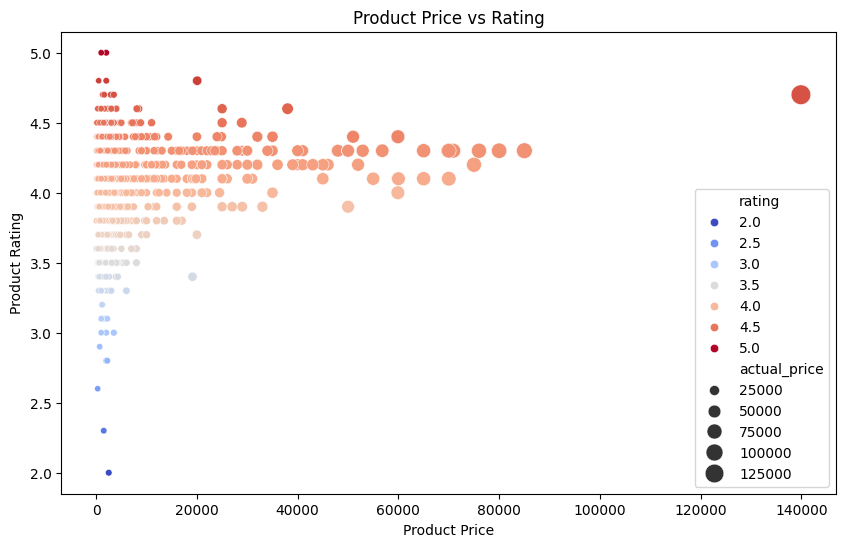

In [13]:
#Price vs Ratings
#Scatter plot to visualize the correlation between price and ratings
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='actual_price', y='rating', hue='rating', palette='coolwarm', size='actual_price', sizes=(20, 200))
plt.title('Product Price vs Rating')
plt.xlabel('Product Price')
plt.ylabel('Product Rating')
plt.show()

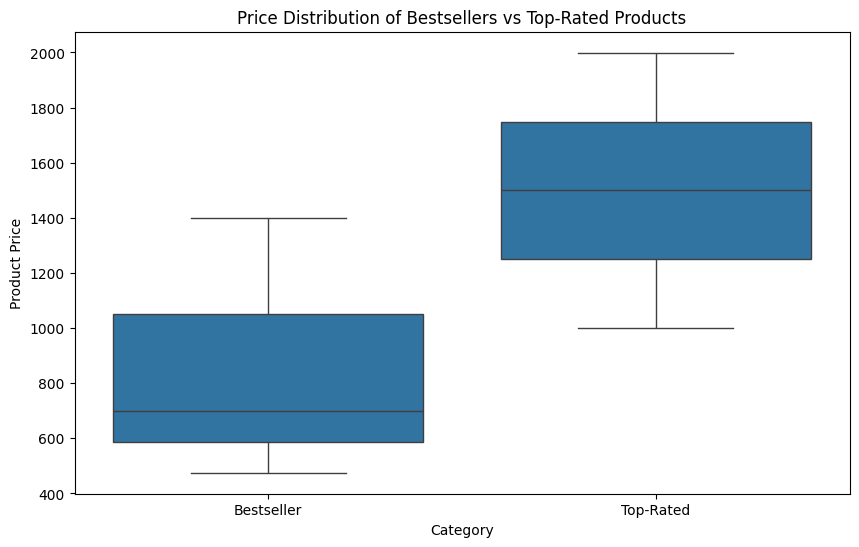

In [14]:
#Best-selling and top-rated product filtering
best_selling = df.loc[df['rating_count'] == df['rating_count'].max()]
top_rated = df.loc[df['rating'] == df['rating'].max()]

#Combine data for plotting
combined = pd.concat([best_selling[['product_name', 'actual_price']], top_rated[['product_name', 'actual_price']]])
combined['Category'] = ['Bestseller' if x in best_selling['product_name'].values else 'Top-Rated' for x in combined['product_name']]

#Boxplot comparing prices of best-selling and top-rated products
plt.figure(figsize=(10, 6))
sns.boxplot(data=combined, x='Category', y='actual_price')
plt.title('Price Distribution of Bestsellers vs Top-Rated Products')
plt.xlabel('Category')
plt.ylabel('Product Price')
plt.show()

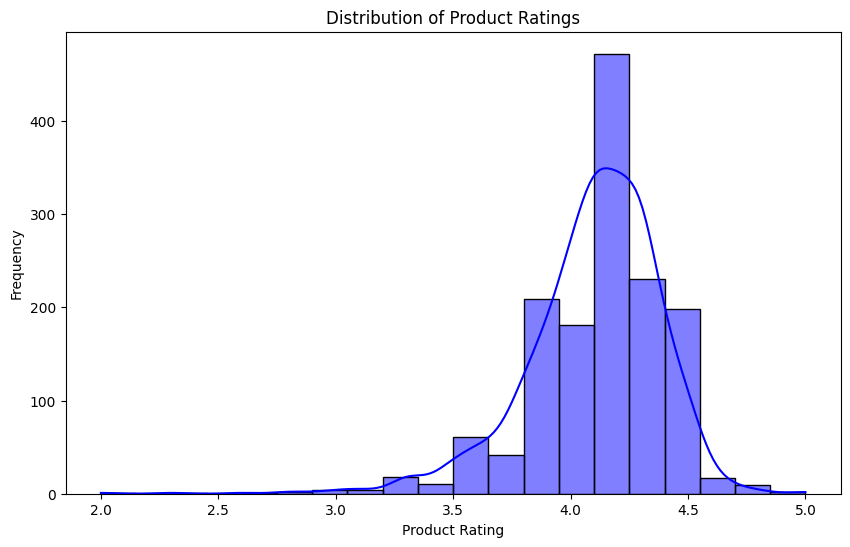

In [15]:
#Distribution of product ratings
plt.figure(figsize=(10, 6))
sns.histplot(df['rating'], kde=True, bins=20, color='blue')
plt.title('Distribution of Product Ratings')
plt.xlabel('Product Rating')
plt.ylabel('Frequency')
plt.show()

### Sentiment Analysis

Sentiment Analysis, also known as opinion mining, is a crucial area within Natural Language Processing (NLP) that involves analyzing textual data to identify and interpret emotions, opinions, or attitudes expressed by individuals. The main goal is to determine the sentiment behind a piece of text—whether it reflects a positive, negative, or neutral viewpoint—toward a specific subject such as a product, service, brand, or event. This technique plays a vital role in understanding public perception, improving customer experience, and guiding business decisions based on user feedback and social media content.

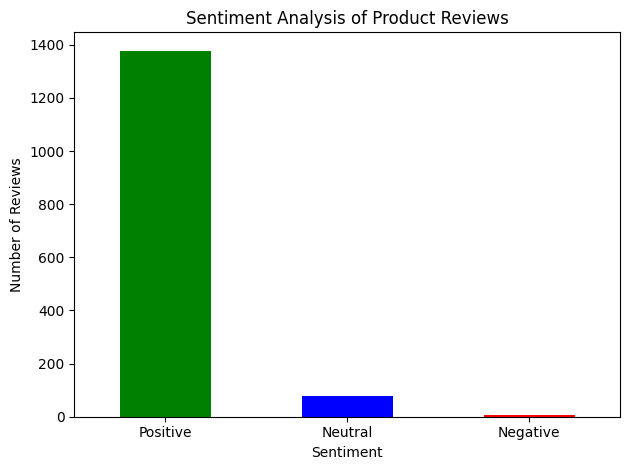

In [16]:
#Function to classify sentiment based on polarity score
def classify_sentiment(text):
    blob = TextBlob(text)
    polarity = blob.sentiment.polarity
    if polarity > 0.1:
        return 'Positive'
    elif polarity < -0.1:
        return 'Negative'
    else:
        return 'Neutral'

#Applying sentiment classification to review_content column
df['sentiment'] = df['review_content'].apply(classify_sentiment)

#count the number of each sentiment category
sentiment_distribution = df['sentiment'].value_counts()

#Ploting the sentiment distribution
sentiment_distribution.plot(
    kind='bar',
    color=['green', 'blue', 'red'],
    title='Sentiment Analysis of Product Reviews'
)
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [50]:
#Finding examples of positive, neutral, and negative sentiments
positive_example = df[df['sentiment'] == 'Positive'].iloc[0]['review_content']
neutral_example = df[df['sentiment'] == 'Neutral'].iloc[0]['review_content']
negative_example = df[df['sentiment'] == 'Negative'].iloc[0]['review_content']

print("Example of sentiment review: ")
example_reviews = pd.DataFrame({
    "Sentiment": ["Positive", "Neutral", "Negative"],
    "Review": [positive_example, neutral_example, negative_example]
})
example_reviews

Example of sentiment review: 


,Sentiment,Review
0,Positive,looks durable charging fine toono complainscharging really fast good product...
1,Neutral,overall goodtv picture ok smart bettersound low another brandservice provide...
2,Negative,value moneyusually gdgood productgoodquality poor responce latethis youve lo...


### Feature Engineering

In [18]:
drop_col = ['discounted_price', 'actual_price', 'discount_percentage', 'review_id', 'review_title',
                   'user_name', 'img_link', 'product_link']
df = df.drop(columns=drop_col)

TF-IDF is a powerful technique used to quantify the importance of words in a document relative to a collection of documents (corpus). It captures not only how frequently a word appears in a document but also how unique or informative that word is across the entire dataset.

Term Frequency (TF): Indicates how often a term appears in a single document, normalized by the total number of terms in that document.

Inverse Document Frequency (IDF): Reflects how significant a term is by reducing the weight of commonly occurring words across documents. It is computed as the logarithm of the total number of documents divided by the number of documents that contain the term.

To generate a more meaningful textual representation of each product, we will combine the product_name, category, and about_product fields. This merged content provides a richer context for TF-IDF to identify keywords that truly define and differentiate each product.

In [19]:
# Combine relevant textual columns to build a rich representation of each product
df['text_corpus'] = (
    df['product_name'].fillna('') + ' ' +
    df['category'].fillna('') + ' ' +
    df['about_product'].fillna('') + ' ' +
    df['review_content'].fillna('')
)

#Initialize the TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(
    stop_words='english',
    max_df=0.95,     #Ignore terms that appear in more than 95% of documents
    min_df=2,        #Ignore terms that appear in fewer than 2 documents
    ngram_range=(1, 1)  #Use unigrams only
)

#Fit the vectorizer and transform the combined text into a TF-IDF matrix
tfidf_matrix = tfidf_vectorizer.fit_transform(df['text_corpus'])

In [20]:
label_encoder = LabelEncoder()
#Fitting the encoder and transforming the 'Sentiment' column
df['Encoded_Sentiment'] = label_encoder.fit_transform(df['sentiment'])

### Content-Based Recommendations

The content-based recommendation approach suggests products by analyzing the textual attributes of items—like product name, category, and description. Using TF-IDF (Term Frequency-Inverse Document Frequency), the model builds a numerical representation of each product. Then, it calculates cosine similarity between products to find those with the most similar textual features. This means if a product shares similar keywords or descriptions with others, it is more likely to be recommended.

This method is especially useful when user behavior or interaction data is limited—allowing recommendations based solely on product metadata.

In [21]:
#Compute cosine similarity between all products based on TF-IDF vectors
cosine_sim = cosine_similarity(tfidf_matrix)

#Check the shape to confirm it matches the number of products
print("Cosine Similarity Matrix Shape:", cosine_sim.shape)

Cosine Similarity Matrix Shape: (1463, 1463)


Since we don’t have user-specific ratings, we can approximate collaborative filtering by aggregating average product ratings.

In [22]:
#Creating a product-user matrix with average product ratings
product_rating_matrix = df.pivot_table(index='product_id', values='rating', aggfunc='mean')

#Filling missing values with the overall average rating
product_rating_matrix = product_rating_matrix.fillna(product_rating_matrix.mean())

#sample of the product-rating matrix
product_rating_matrix.head()

,rating
product_id,
B002PD61Y4,4.1
B002SZEOLG,4.2
B003B00484,4.3
B003L62T7W,4.3
B004IO5BMQ,4.5


### Hybrid Recommendation System

Implementing a Hybrid Recommendation System that merges Content-Based Filtering and a form of Collaborative Filtering to suggest products similar to a given one.

The content-based part uses a TF-IDF representation of product-related text (such as name, category, and description) and computes cosine similarity to find items with similar textual attributes. The collaborative part relies on average product ratings, assuming products with similar user ratings reflect shared user preferences.

By combining both recommendation strategies—semantic similarity and rating similarity—we can generate more well-rounded suggestions that consider both what a product is and how users perceive it.

In [23]:
def get_hybrid_recommendations(target_product_id, similarity_matrix, rating_matrix, product_df, top_n=10):
    """
    Returns top N hybrid recommendations for a given product using content-based,
    collaborative filtering, and fallback strategies.
    """

    #Jaccard similarity filter to avoid near-duplicate names
    def is_duplicate(name1, name2, threshold=0.85):
        set1 = set(name1.lower().split())
        set2 = set(name2.lower().split())
        intersection = len(set1.intersection(set2))
        union = len(set1.union(set2))
        return (intersection / union) > threshold if union > 0 else False

    #index of the target product
    try:
        product_idx = product_df.index[product_df['product_id'] == target_product_id][0]
    except IndexError:
        print("Product ID not found in dataset.")
        return pd.DataFrame()
        
    #Getting target product information (fetches the specific row of information for the product we need recommendations from
    target_product = product_df.loc[product_idx]
    target_name = target_product['product_name']
    target_keywords = set(target_name.lower().split())

    #Content-Based Filtering
    similarity_scores = list(enumerate(similarity_matrix[product_idx])) #Gets cosine similarity scores between the target prodcut and all others.
    sorted_scores = sorted(similarity_scores, key=lambda x: x[1], reverse=True) #Sorting by similarity, highest to lowest

    content_indices = []
    for idx, score in sorted_scores[1:]: #Getting top_n similar that are not near duplicates.
        other_name = product_df.iloc[idx]['product_name']
        if not is_duplicate(target_name, other_name):
            content_indices.append((idx, score))
        if len(content_indices) >= top_n:
            break

    #Collaborative Filtering
    collab_indices = []
    if target_product_id in rating_matrix.index: #checking if product has an average rating available
        target_rating = rating_matrix.loc[target_product_id].values[0] #Getting the products rating
        rating_diffs = abs(rating_matrix['rating'] - target_rating) 
        similar_rated = rating_diffs.nsmallest(top_n).index.tolist() ##Finding products with similar ratings

        for pid in similar_rated:
            if pid == target_product_id:
                continue
            if pid in product_df['product_id'].values:
                idx = product_df.index[product_df['product_id'] == pid][0]
                collab_indices.append((idx, 1 / (1 + abs(rating_matrix.loc[pid]['rating'] - target_rating)))) #Gives higher scores to closer ratings

    # ----- Combine Content + Collaborative -----
    final_scores = {}

    #Content weights (e.g., 70%) [Higher is giving better results]
    for idx, sim_score in content_indices:
        final_scores[idx] = final_scores.get(idx, 0) + 0.95 * sim_score

    #Collaborative weights (e.g., 30%)[Lower is giving better results]
    for idx, score in collab_indices:
        final_scores[idx] = final_scores.get(idx, 0) + 0.05 * score

    #Sorting combined results
    ranked = sorted(final_scores.items(), key=lambda x: x[1], reverse=True)
    recommended_indices = [idx for idx, _ in ranked]

    #Fallback Layer: Keyword Overlap
    if len(recommended_indices) < top_n: #Only used when recommendations list has fewer than required top_n recommendations
        fallback_candidates = product_df[
            (product_df['product_id'] != target_product_id)
        ].copy() #Copies all products that are not the product for which we are finding recommendations.

        
        #For each candidate, calculate how many keywords from the target product name appear in its name
        fallback_candidates['keyword_overlap'] = fallback_candidates['product_name'].apply(
            lambda x: len(set(x.lower().split()).intersection(target_keywords))
        )
        keyword_matches = fallback_candidates.sort_values(by='keyword_overlap', ascending=False)
        #Sort products by how much their name overlaps with the target product's name
        
        for _, row in fallback_pool.iterrows():
            fallback_idx = product_df.index[product_df['product_id'] == row['product_id']][0]
            if fallback_idx not in recommended_indices and not is_duplicate(target_name, row['product_name']):
                recommended_indices.append(fallback_idx)
            #Only add if it’s not already in the list and it's not a near-duplicate
            if len(recommended_indices) >= top_n:
                break

    #Final Output
    top_indices = recommended_indices[:top_n]
    recommended_df = product_df.iloc[top_indices][['product_id', 'product_name', 'rating']].copy()

    return recommended_df

### Displaying Recommendations

In [24]:
def display_recommendations(product_id, recommendations_df, original_df):
    #Getring the name of the original product
    try:
        original_product_name = original_df.loc[original_df['product_id'] == product_id, 'product_name'].values[0]
    except IndexError:
        print("Product ID not found in the dataset.")
        return

    print(f"\n **Recommendations for Product ID: {product_id}**")
    print(f" **Original Product:** {original_product_name}\n")

    #Reset index for neat output
    recommendations_df = recommendations_df.reset_index(drop=True)

    print("**Top Recommended Products:**\n")
    display(recommendations_df[['product_id', 'product_name', 'rating']])

In [45]:
random_product_id = df.sample(1)['product_id'].values[0]
recommended_df = get_hybrid_recommendations(random_product_id, cosine_sim, product_rating_matrix, df, top_n=5)

In [46]:
display_recommendations(random_product_id, recommended_df, df)


 **Recommendations for Product ID: B07BRKK9JQ**
 **Original Product:** zebronics zebtransformer gaming keyboard mouse combo usb braided cable

**Top Recommended Products:**



,product_id,product_name,rating
0,B07KR5P3YD,zebronics wired keyboard mouse combo 104 keys usb mouse 1200 dpi judwaa 750,3.9
1,B00CEQEGPI,logitech mk270r usb wireless keyboard mouse set windows 24 ghz wireless spil...,4.2
2,B0BHYJ8CVF,portronics key2 combo multimedia usb wireless keyboard mouse set 24 ghz wire...,4.1
3,B09GBBJV72,hp 330 wireless black keyboard mouse set numeric keypad 24ghz wireless conne...,3.9
4,B087FXHB6J,zebronics zebcompanion 107 usb wireless keyboard mouse set nano receiver black,3.5


### Creating ground truth

Since we do not have the truth labels in our dataset we can not know if a given recommendation is relevant or irrelevant (no explicit labels for relevance). 

In order to calculate key metrics such as precision and MAP we need to have ground truth labels. In order to simulate ground truth we will apply the strategy of content similarity based ground truth. 

- We compute TF-IDF vectors of product names and use **cosine similarity** to measure content similarity between products.
- For each product, the top-N most similar products (excluding itself) with **cosine similarity above a threshold** (e.g., 0.4) are treated as its *relevant* or *similar* items.
- This threshold is a **hyperparameter** that controls the tradeoff between quality (precision) and quantity (recall) of ground truth labels.

In [36]:
#Reseting index to ensure it's numeric
df = df.reset_index(drop=True)

#cecking shape of TF-IDF and aligning to not get shape mismatch errors
df_tfidf = df.iloc[:tfidf_matrix.shape[0]]  #Ensures alignment

#Building ground truth with backup
ground_truth = {}
similarity_threshold = 0.4  #Can be tuned(hyperparameter) to balance relevance vs coverage

for idx, row in df_tfidf.iterrows():
    product_id = row['product_id']
    product_name = row['product_name']
    
    #Get primary content-based similar indices excluding exact match
    similar_indices = [
        i for i, score in enumerate(cosine_sim[idx])
        if i != idx and score > similarity_threshold
    ]

    #Filter out products with identical names(exact duplicates)
    similar_product_ids = []
    for i in similar_indices:
        other_name = df_tfidf.iloc[i]['product_name']
        if other_name.strip().lower() != product_name.strip().lower():
            similar_product_ids.append(df_tfidf.iloc[i]['product_id'])

    #If not enough similar items, use category-based fallback
    if len(similar_product_ids) < 3:  #tune this threshold(hyperparameter)
        category = row.get('category', None)
        if category:
            fallback_products = df_tfidf[
                (df_tfidf['category'] == category) &
                (df_tfidf['product_id'] != product_id)
            ]['product_id'].tolist()

            #add fallback products until at least 5 similar items are reached
            for pid in fallback_products:
                if pid not in similar_product_ids:
                    similar_product_ids.append(pid)
                if len(similar_product_ids) >= 5:
                    break

    #Assign to ground truth
    ground_truth[product_id] = similar_product_ids

In [37]:
#Checking ground truth and similarities
gt_lengths = [len(v) for v in ground_truth.values()]
print(f"Average # of similar products per product in ground truth: {np.mean(gt_lengths):.2f}")
print(f"Median: {np.median(gt_lengths)}, Max: {np.max(gt_lengths)}, Min: {np.min(gt_lengths)}")

Average # of similar products per product in ground truth: 5.91
Median: 5.0, Max: 44, Min: 0


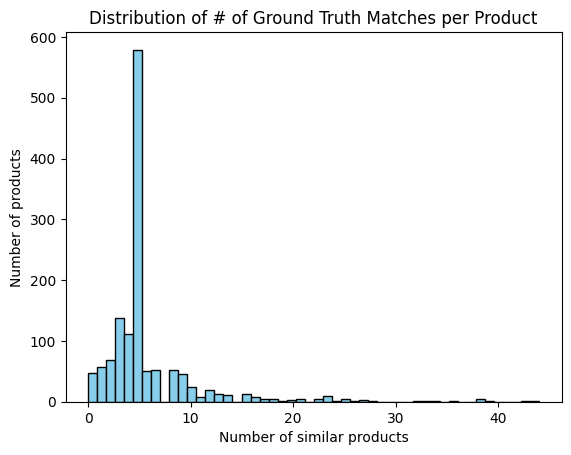

In [38]:
plt.hist(gt_lengths, bins=50, color='skyblue', edgecolor='black')
plt.title("Distribution of # of Ground Truth Matches per Product")
plt.xlabel("Number of similar products")
plt.ylabel("Number of products")
plt.show()

### Evaluating the hybrid recommendation system using several evaluation metrics such as 

- **MAP@K**: Mean of Average Precision scores across all queries/items. Reflects both relevance and ranking quality across the dataset.
- **Precision@K**: Proportion of top-K recommended items that are relevant. Measures recommendation accuracy.
- **Recall@K**: Proportion of relevant items retrieved in the top-K recommendations. Measures recommendation completeness.
- **F1@K**: Harmonic mean of Precision@K and Recall@K. Balances accuracy and coverage.
- **Hit Rate@K**: Percentage of users/items with at least one relevant recommendation in top-K. Reflects overall success rate.
- **NDCG@K**: Normalized Discounted Cumulative Gain at K. Evaluates ranking quality by emphasizing position of relevant items.



In [47]:
def precision_at_k(recommended, relevant, k=10):
    recommended_k = recommended[:k]
    relevant_set = set(relevant)
    hits = sum([1 for item in recommended_k if item in relevant_set])
    return hits / k

def recall_at_k(recommended, relevant, k=10):
    recommended_k = recommended[:k]
    relevant_set = set(relevant)
    if not relevant:
        return 0.0
    hits = sum([1 for item in recommended_k if item in relevant_set])
    return hits / len(relevant_set)

def f1_score_at_k(precision, recall):
    if precision + recall == 0:
        return 0.0
    return 2 * (precision * recall) / (precision + recall)

def hit_rate_at_k(recommended, relevant, k=10):
    recommended_k = recommended[:k]
    return int(any(item in relevant for item in recommended_k))

def ndcg_at_k(recommended, relevant, k=10):
    dcg = 0.0
    for i, item in enumerate(recommended[:k]):
        if item in relevant:
            dcg += 1 / np.log2(i + 2)  # log2(i+2) to avoid log2(1)=0
    ideal_hits = min(len(relevant), k)
    idcg = sum([1 / np.log2(i + 2) for i in range(ideal_hits)])
    return dcg / idcg if idcg > 0 else 0.0

def average_precision_at_k(recommended, relevant, k=10):
    if not relevant:
        return 0.0
    score = 0.0
    hits = 0
    for i, item in enumerate(recommended[:k]):
        if item in relevant:
            hits += 1
            score += hits / (i + 1)
    return score / min(len(relevant), k)

In [48]:
all_recommendations = {}


for pid in df_tfidf['product_id'].values:
    try:
        recs = get_hybrid_recommendations(pid, cosine_sim, product_rating_matrix, df_tfidf, top_n=10)
        rec_product_ids = recs['product_id'].tolist()
        all_recommendations[pid] = rec_product_ids
    except IndexError:
        continue


total_precision, total_recall, total_f1 = 0.0, 0.0, 0.0
total_hits, total_ndcg, total_map = 0.0, 0.0, 0.0
num_products = 0

for pid in all_recommendations:
    recommended = all_recommendations[pid]
    relevant = ground_truth.get(pid, [])

    if not relevant:
        continue

    prec = precision_at_k(recommended, relevant, k=10)
    rec = recall_at_k(recommended, relevant, k=10)
    f1 = f1_score_at_k(prec, rec)
    hit = hit_rate_at_k(recommended, relevant, k=10)
    ndcg = ndcg_at_k(recommended, relevant, k=10)
    ap = average_precision_at_k(recommended, relevant, k=10)

    total_precision += prec
    total_recall += rec
    total_f1 += f1
    total_hits += hit
    total_ndcg += ndcg
    total_map += ap
    num_products += 1

print(f"Evaluation Metrics @10 (on {num_products} products)")
print(f"  • Precision@10: {total_precision / num_products:.4f}")
print(f"  • Recall@10:    {total_recall / num_products:.4f}")
print(f"  • F1@10:        {total_f1 / num_products:.4f}")
print(f"  • Hit Rate@10:  {total_hits / num_products:.4f}")
print(f"  • NDCG@10:      {total_ndcg / num_products:.4f}")
print(f"\nMean Average Precision at 10 (MAP@10): {total_map / num_products:.4f}")

Evaluation Metrics @10 (on 1301 products)
  • Precision@10: 0.4251
  • Recall@10:    0.7986
  • F1@10:        0.5113
  • Hit Rate@10:  0.9523
  • NDCG@10:      0.7692

Mean Average Precision at 10 (MAP@10): 0.7068
